In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [10]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [11]:
test.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [12]:
print(train['SalePrice'].describe())

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


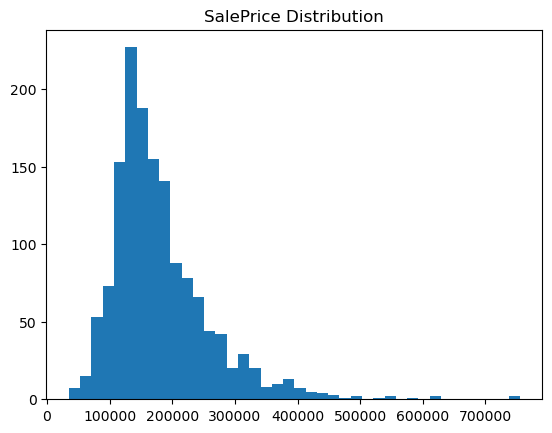

In [14]:
plt.hist(train['SalePrice'],bins = 40)
plt.title("SalePrice Distribution")
plt.show()

In [17]:
print(train.isnull().sum().sort_values(ascending=False).head(10))

PoolQC         1453
MiscFeature    1406
Alley          1369
Fence          1179
MasVnrType      872
FireplaceQu     690
LotFrontage     259
GarageYrBlt      81
GarageCond       81
GarageType       81
dtype: int64


In [45]:
features = ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea',
            'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd',
            'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'Fireplaces']

In [46]:
corr = train[features + ['SalePrice']].corr()['SalePrice'].sort_values(ascending=False)
print(corr)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
MasVnrArea      0.477493
Fireplaces      0.466929
Name: SalePrice, dtype: float64


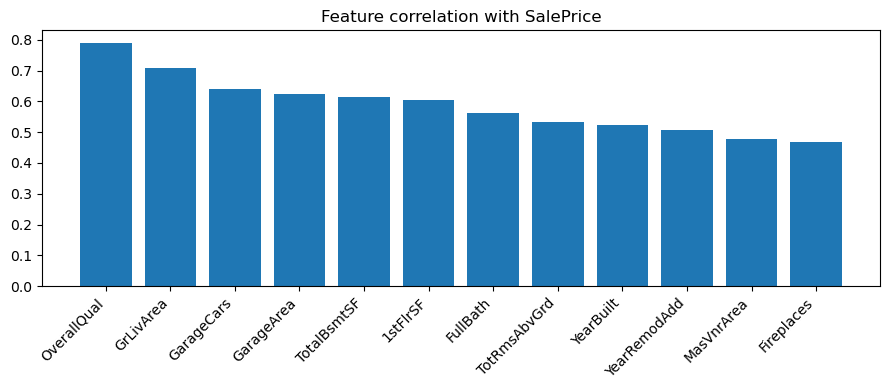

In [47]:
plt.figure(figsize=(9, 4))
plt.bar(corr.index[1:], corr.values[1:])
plt.xticks(rotation=45, ha='right')
plt.title("Feature correlation with SalePrice")
plt.tight_layout()

Text(0.5, 1.0, 'GrLivArea vs SalePrice (check outliers)')

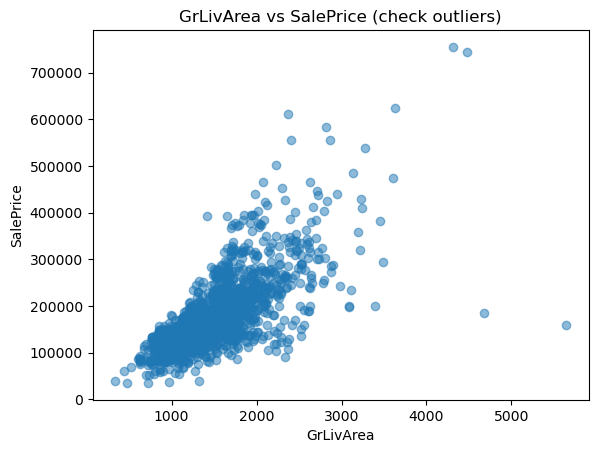

In [48]:
plt.scatter(train['GrLivArea'], train['SalePrice'], alpha=0.5)
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.title("GrLivArea vs SalePrice (check outliers)")

Text(0, 0.5, 'SalePrice')

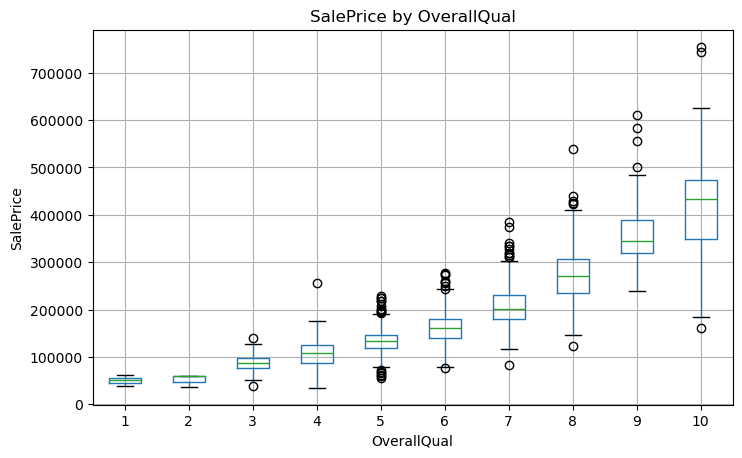

In [49]:
train.boxplot(column='SalePrice', by='OverallQual', figsize=(8, 5))
plt.title("SalePrice by OverallQual")
plt.suptitle("")
plt.ylabel("SalePrice")

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [51]:
X = train[features].fillna(0)
y = train['SalePrice']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
pred = model.predict(X_val)
mse = mean_squared_error(y_val, pred)
r2 = r2_score(y_val, pred)
print(f"MSE: {mse:.2f}")
print(f"R2 Score: {r2:.3f}")

MSE: 1475689949.21
R2 Score: 0.808


In [39]:
comparison = pd.DataFrame({'Actual': y_val.values, 'Predicted': pred})
print(comparison.head(10))

   Actual      Predicted
0  154500  146718.942483
1  325000  305973.351926
2  115000  117166.238915
3  159000  173904.275084
4  315500  287997.143841
5   75500   54904.434380
6  311500  235376.734442
7  146000  170279.153880
8   84500   53637.424462
9  135500  118399.709791


Text(0.5, 1.0, 'Actual vs Predicted')

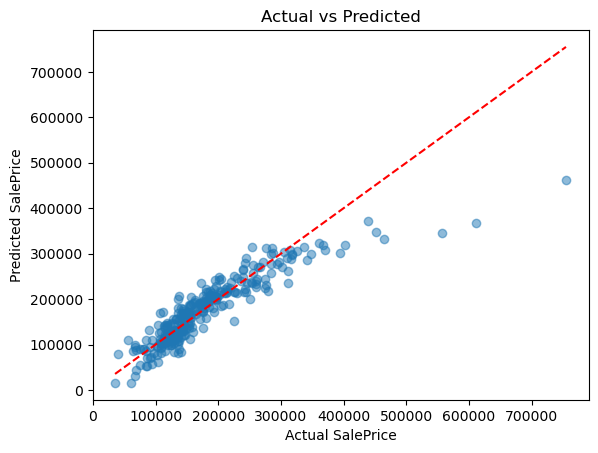

In [54]:
plt.scatter(y_val, pred, alpha=0.5)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Actual vs Predicted")

In [55]:
X_test = test[features].fillna(0)
test_pred = model.predict(X_test)

In [56]:
submission = pd.DataFrame({'Id': test['Id'], 'SalePrice': test_pred})
submission.to_csv("submission_v2.csv", index=False)
print(submission.head())

     Id      SalePrice
0  1461  108136.331323
1  1462  148963.975352
2  1463  173368.843537
3  1464  191806.110042
4  1465  207748.104503
